In [1]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import confusion_matrix, adjusted_rand_score
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#loading files
df_median = pd.read_csv("all_features_median_after_detrended.csv")
df_outlier = pd.read_csv("all_features_outliercleaned.csv")
df_raw = pd.read_csv("all_features_raw.csv")

#choosing features 
features = ['Period', 'Amplitud', 'Rcs', 'Stetsonk', 'Mean_variance', 'Eta_e']

In [3]:
top5 = df_median['type'].value_counts().head(5).index.tolist()
print("Top 5 clases:", top5)

Top 5 clases: ['EW', 'SR', 'ROT', 'EA', 'RRAB']


In [4]:
mask = df_median['type'].isin(top5)
X = df_median.loc[mask, features].values
y_text = df_median.loc[mask, 'type'].values


In [5]:
# scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
#encode
le = LabelEncoder()
y = le.fit_transform(y_text)
class_names = le.classes_

In [6]:
#k-means aplicartions
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

In [7]:
#matching clusters 
y_pred = np.zeros_like(y)
for i in range(5):
    mask_cluster = (clusters == i)
    if mask_cluster.any():

        try:
            from scipy.stats import mode
            majority = mode(y[mask_cluster], keepdims=True)[0][0]
        except:
            majority = np.bincount(y[mask_cluster]).argmax()
        y_pred[mask_cluster] = majority

In [8]:
#confusion matrix 
cm = confusion_matrix(y, y_pred)
accuracy = np.sum(np.diag(cm)) / np.sum(cm)
ari = adjusted_rand_score(y, clusters)

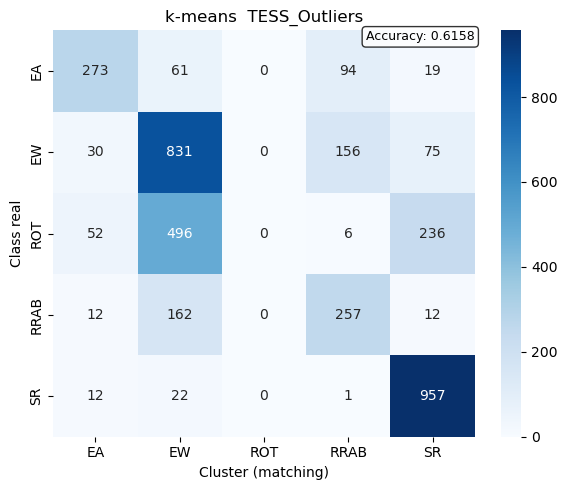

In [9]:
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Cluster (matching)')
plt.ylabel('Class real')
plt.title(f'k-means  TESS_Outliers')

# Añadir texto con accuracy y ARI dentro de la figura
plt.text(1, 1, f'Accuracy: {accuracy:.4f}',
         transform=plt.gca().transAxes, ha='right', va='top',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
         fontsize=9)

plt.tight_layout()
plt.savefig("k_means_outliers.png", dpi=300)
plt.show()

In [10]:
print("Matriz de confusión:\n", cm)
print(f"\nAccuracy: {accuracy:.4f}")
print(f"Adjusted Rand Index (ARI): {ari:.4f}")

Matriz de confusión:
 [[273  61   0  94  19]
 [ 30 831   0 156  75]
 [ 52 496   0   6 236]
 [ 12 162   0 257  12]
 [ 12  22   0   1 957]]

Accuracy: 0.6158
Adjusted Rand Index (ARI): 0.3210


In [ ]:
print("Mapeo de clases:")
for i, clase in enumerate(le.classes_):
    print(f"  {i} -> {clase}")